In [ ]:
!wget https://raw.githubusercontent.com/maziarraissi/PINNs/master/main/Data/cylinder_nektar_wake.mat
!wget https://raw.githubusercontent.com/maziarraissi/PINNs/master/main/Data/cylinder_nektar_t0_vorticity.mat
!wget https://raw.githubusercontent.com/maziarraissi/PINNs/master/Utilities/plotting.py

--2026-06-09 09:27:00--  https://raw.githubusercontent.com/maziarraissi/PINNs/master/main/Data/cylinder_nektar_wake.mat
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 24081984 (23M) [application/octet-stream]
Saving to: ‘cylinder_nektar_wake.mat.4’

cylinder_nektar_wak 100%[===================>]  22.97M  --.-KB/s    in 0.1s    

2026-06-09 09:27:01 (194 MB/s) - ‘cylinder_nektar_wake.mat.4’ saved [24081984/24081984]

--2026-06-09 09:27:01--  https://raw.githubusercontent.com/maziarraissi/PINNs/master/main/Data/cylinder_nektar_t0_vorticity.mat
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... conne

In [ ]:
!apt-get update
!apt-get install texlive-latex-extra texlive-fonts-recommended dvipng cm-super -y

Hit:1 https://cli.github.com/packages stable InRelease
Hit:2 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease
Hit:3 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease
Hit:4 http://archive.ubuntu.com/ubuntu jammy InRelease
Hit:5 http://security.ubuntu.com/ubuntu jammy-security InRelease
Hit:6 http://archive.ubuntu.com/ubuntu jammy-updates InRelease
Hit:7 http://archive.ubuntu.com/ubuntu jammy-backports InRelease
Hit:8 https://r2u.stat.illinois.edu/ubuntu jammy InRelease
Hit:9 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:10 https://ppa.launchpadcontent.net/graphics-drivers/ppa/ubuntu jammy InRelease
Hit:11 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Reading package lists... Done
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading packag

In [ ]:
import matplotlib as mpl
mpl.use('pgf') # Set the backend before importing pyplot
import matplotlib.pyplot as plt

def newfig(width, height):
    fig = plt.figure(figsize=(width, height))
    ax = fig.add_subplot(111)
    return fig, ax

def savefig(path):
    plt.savefig(path + '.pdf')
    plt.savefig(path + '.eps')

# Corrected content for plotting.py built by concatenation to prevent truncation
corrected_plotting_content = (
    "import matplotlib as mpl\n"
    "mpl.use('pgf') # Set the backend before importing pyplot\n"
    "import matplotlib.pyplot as plt\n\n"
    "def newfig(width, height):\n"
    "    fig = plt.figure(figsize=(width, height))\n"
    "    ax = fig.add_subplot(111)\n"
    "    return fig, ax\n\n"
    "def savefig(path):\n"
    "    plt.savefig(path + '.pdf')\n"
    "    plt.savefig(path + '.eps')\n\n\n"
    "mpl.rcParams['text.usetex'] = True\n"
    "mpl.rcParams['font.family'] = 'serif'\n"
    "mpl.rcParams['font.serif'] = 'Computer Modern Roman'\n\n"
    "pgf_with_latex = {\n"
    "    \"pgf.texsystem\": \"pdflatex\",\n"
    "    \"pgf.rcfonts\": False,\n"
    "    \"text.usetex\": True,\n"
    "    \"font.family\": \"serif\",\n"
    "    \"font.serif\": [],\n"
    "    \"font.sans-serif\": [],\n"
    "    \"font.monospace\": [],\n"
    "    \"axes.labelsize\": 10,\n"
    "    \"font.size\": 10,\n"
    "    \"legend.fontsize\": 10,\n"
    "    \"xtick.labelsize\": 8,\n"
    "    \"ytick.labelsize\": 8,\n"
    "    \"pgf.preamble\": \"\\n\".join([\n"
    "        \"\\\\usepackage[utf8x]{inputenc}\",    # use utf8 fonts becasue your computer is fucking awesome\n"
    "        \"\\\\usepackage[T1]{fontenc}\",        # plots will be generated with this preamble\n"
    "        ])\n"
    "}\n"
    "mpl.rcParams.update(pgf_with_latex)\n"
)

with open('plotting.py', 'w') as f:
    f.write(corrected_plotting_content)

print("plotting.py has been updated.")


plotting.py has been updated.


In [ ]:
from google.colab import drive
import os

# Montar Google Drive
drive.mount('/content/drive')

# Crear la carpeta para los checkpoints si no existe
checkpoint_noiseless_dir = '/content/drive/MyDrive/PINN_checkpoints/noiseless'
checkpoint_noisy_dir = '/content/drive/MyDrive/PINN_checkpoints/noisy'
if not os.path.exists(checkpoint_noiseless_dir):
    os.makedirs(checkpoint_noiseless_dir)
    print("Carpeta noiseless creada en tu Google Drive!")

if not os.path.exists(checkpoint_noisy_dir):
    os.makedirs(checkpoint_noisy_dir)
    print("Carpeta noisy creada en tu Google Drive!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os
import shutil

# 1. Definir las rutas
ruta_raiz = '/content/drive/MyDrive/PINN_checkpoints/'
ruta_noiseless = '/content/drive/MyDrive/PINN_checkpoints/noiseless/'


# 2. Mover todos los archivos sueltos de la raíz a la subcarpeta noiseless
archivos_movidos = 0
for nombre_archivo in os.listdir(ruta_raiz):
    origen = os.path.join(ruta_raiz, nombre_archivo)
    destino = os.path.join(ruta_noiseless, nombre_archivo)

    # Solo movemos archivos (no subcarpetas)
    if os.path.isfile(origen):
        shutil.move(origen, destino)
        archivos_movidos += 1

print(f"¡Listo! Se han movido {archivos_movidos} archivos a la carpeta 'noiseless'.")
print("Ya puedes ejecutar el código modificado con total seguridad.")

¡Listo! Se han movido 0 archivos a la carpeta 'noiseless'.
Ya puedes ejecutar el código modificado con total seguridad.


In [ ]:
import sys
# sys.path.insert(0, '../../Utilities/') # Eliminado porque plotting.py ahora está en la carpeta raíz

# Compatibilidad con TensorFlow 1.x para Colab
import tensorflow.compat.v1 as tf
tf.disable_v2_behavior()

import numpy as np
import matplotlib.pyplot as plt
import scipy.io
from scipy.interpolate import griddata
import time
from itertools import product, combinations
from mpl_toolkits.mplot3d import Axes3D
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

# Modificamos la importación de plotting para cargar la clase directamente
from plotting import newfig, savefig, mpl

from mpl_toolkits.axes_grid1 import make_axes_locatable
import matplotlib.gridspec as gridspec

np.random.seed(1234)
tf.set_random_seed(1234)

# Modificación para corregir el error de 'pgf.preamble'
# original `pgf_with_latex['pgf.preamble']` is a list, but it expects a string.
# Joining the list elements into a single string.
pgf_with_latex = {
    "pgf.texsystem": "pdflatex",
    "pgf.rcfonts": False,
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": [],
    "font.sans-serif": [],
    "font.monospace": [],
    "axes.labelsize": 10,
    "font.size": 10,
    "legend.fontsize": 10,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "pgf.preamble": "\n".join(['\\usepackage[utf8x]{inputenc}', '\\usepackage[T1]{fontenc}'])
}
mpl.rcParams.update(pgf_with_latex)


class PhysicsInformedNN:
    # Initialize the class
    def __init__(self, x, y, t, u, v, layers, case_type='noiseless'):

        X = np.concatenate([x, y, t], 1)

        self.lb = X.min(0)
        self.ub = X.max(0)

        self.X = X

        self.x = X[:,0:1]
        self.y = X[:,1:2]
        self.t = X[:,2:3]

        self.u = u
        self.v = v

        self.layers = layers

        # Initialize NN
        self.weights, self.biases = self.initialize_NN(layers)

        # Initialize parameters
        self.lambda_1 = tf.Variable([0.0], dtype=tf.float32)
        self.lambda_2 = tf.Variable([0.0], dtype=tf.float32)

        # tf placeholders and graph
        self.sess = tf.Session(config=tf.ConfigProto(allow_soft_placement=True,
                                                     log_device_placement=True))

        self.x_tf = tf.placeholder(tf.float32, shape=[None, self.x.shape[1]])
        self.y_tf = tf.placeholder(tf.float32, shape=[None, self.y.shape[1]])
        self.t_tf = tf.placeholder(tf.float32, shape=[None, self.t.shape[1]])

        self.u_tf = tf.placeholder(tf.float32, shape=[None, self.u.shape[1]])
        self.v_tf = tf.placeholder(tf.float32, shape=[None, self.v.shape[1]])

        self.u_pred, self.v_pred, self.p_pred, self.f_u_pred, self.f_v_pred = self.net_NS(self.x_tf, self.y_tf, self.t_tf)

        self.loss = tf.reduce_sum(tf.square(self.u_tf - self.u_pred)) + \
                    tf.reduce_sum(tf.square(self.v_tf - self.v_pred)) + \
                    tf.reduce_sum(tf.square(self.f_u_pred)) + \
                    tf.reduce_sum(tf.square(self.f_v_pred))

        # Removed ScipyOptimizerInterface due to tf.contrib removal
        # self.optimizer = tf.contrib.opt.ScipyOptimizerInterface(self.loss,
        #                                                         method = 'L-BFGS-B',
        #                                                         options = {'maxiter': 50000,
        #                                                                    'maxfun': 50000,
        #                                                                    'maxcor': 50,
        #                                                                    'maxls': 50,
        #                                                                    'ftol' : 1.0 * np.finfo(float).eps})

        self.optimizer_Adam = tf.train.AdamOptimizer()
        self.train_op_Adam = self.optimizer_Adam.minimize(self.loss)

        init = tf.global_variables_initializer()
        self.sess.run(init)

        # --- MODIFICADO PARA SEPARAR CARPETAS ---
        self.model_dir = f'/content/drive/MyDrive/PINN_checkpoints/{case_type}/'
        self.checkpoint_path = self.model_dir + 'model.ckpt'
        self.saver = tf.train.Saver(max_to_keep=2)

    def initialize_NN(self, layers):
        weights = []
        biases = []
        num_layers = len(layers)
        for l in range(0,num_layers-1):
            W = self.xavier_init(size=[layers[l], layers[l+1]])
            b = tf.Variable(tf.zeros([1,layers[l+1]], dtype=tf.float32), dtype=tf.float32)
            weights.append(W)
            biases.append(b)
        return weights, biases

    def xavier_init(self, size):
        in_dim = size[0]
        out_dim = size[1]
        xavier_stddev = np.sqrt(2/(in_dim + out_dim))
        return tf.Variable(tf.truncated_normal([in_dim, out_dim], stddev=xavier_stddev), dtype=tf.float32)

    def neural_net(self, X, weights, biases):
        num_layers = len(weights) + 1

        H = 2.0*(X - self.lb)/(self.ub - self.lb) - 1.0
        for l in range(0,num_layers-2):
            W = weights[l]
            b = biases[l]
            H = tf.tanh(tf.add(tf.matmul(H, W), b))
        W = weights[-1]
        b = biases[-1]
        Y = tf.add(tf.matmul(H, W), b)
        return Y

    def net_NS(self, x, y, t):
        lambda_1 = self.lambda_1
        lambda_2 = self.lambda_2

        psi_and_p = self.neural_net(tf.concat([x,y,t], 1), self.weights, self.biases)
        psi = psi_and_p[:,0:1]
        p = psi_and_p[:,1:2]

        u = tf.gradients(psi, y)[0]
        v = -tf.gradients(psi, x)[0]

        u_t = tf.gradients(u, t)[0]
        u_x = tf.gradients(u, x)[0]
        u_y = tf.gradients(u, y)[0]
        u_xx = tf.gradients(u_x, x)[0]
        u_yy = tf.gradients(u_y, y)[0]

        v_t = tf.gradients(v, t)[0]
        v_x = tf.gradients(v, x)[0]
        v_y = tf.gradients(v, y)[0]
        v_xx = tf.gradients(v_x, x)[0]
        v_yy = tf.gradients(v_y, y)[0]

        p_x = tf.gradients(p, x)[0]
        p_y = tf.gradients(p, y)[0]

        f_u = u_t + lambda_1*(u*u_x + v*u_y) + p_x - lambda_2*(u_xx + u_yy)
        f_v = v_t + lambda_1*(u*v_x + v*v_y) + p_y - lambda_2*(v_xx + v_yy)

        return u, v, p, f_u, f_v

    def callback(self, loss, lambda_1, lambda_2):
        print('Loss: %.3e, l1: %.3f, l2: %.5f' % (loss, lambda_1, lambda_2))

    def train(self, nIter):

        tf_dict = {self.x_tf: self.x, self.y_tf: self.y, self.t_tf: self.t,
                   self.u_tf: self.u, self.v_tf: self.v}

        # --- AÑADIDO: Intentar restaurar checkpoint previo si existe ---
        ckpt = tf.train.get_checkpoint_state(self.model_dir)
        if ckpt and ckpt.model_checkpoint_path:
            self.saver.restore(self.sess, ckpt.model_checkpoint_path)
            print(f"=================================================")
            print(f"Checkpoint restaurado desde: {ckpt.model_checkpoint_path}")
            print(f"=================================================")
        else:
            print(f"No se encontró checkpoint en {self.model_dir}. Iniciando desde cero.")

        start_time = time.time()
        for it in range(nIter):
            self.sess.run(self.train_op_Adam, tf_dict)

            # Print
            if it % 10 == 0:
                elapsed = time.time() - start_time
                loss_value = self.sess.run(self.loss, tf_dict)
                lambda_1_value = self.sess.run(self.lambda_1)
                lambda_2_value = self.sess.run(self.lambda_2)
                print('It: %d, Loss: %.3e, l1: %.3f, l2: %.5f, Time: %.2f' %
                      (it, loss_value, lambda_1_value, lambda_2_value, elapsed))
                start_time = time.time()

            # --- AÑADIDO: Guardar checkpoint cada 10,000 iteraciones ---
            if it % 10000 == 0 and it > 0:
                self.saver.save(self.sess, self.checkpoint_path, global_step=it)
                print(f"--> Checkpoint guardado en la iteración {it} en tu Google Drive.")

        # Al finalizar Adam, guardamos el estado final antes de pasar a L-BFGS-B
        self.saver.save(self.sess, self.checkpoint_path, global_step=nIter)

        # Optimizador Scipy L-BFGS-B (se mantiene igual) - REMOVED CALL AS IT'S NOT INITIALIZED
        # self.optimizer.minimize(self.sess,
        #                         feed_dict = tf_dict,
        #                         fetches = [self.loss, self.lambda_1, self.lambda_2],
        #                         loss_callback = self.callback)

        # Guardar el modelo completamente optimizado al final
        # self.saver.save(self.sess, self.checkpoint_path, global_step=nIter + 1)


    def predict(self, x_star, y_star, t_star):

        tf_dict = {self.x_tf: x_star, self.y_tf: y_star, self.t_tf: t_star}

        u_star = self.sess.run(self.u_pred, tf_dict)
        v_star = self.sess.run(self.v_pred, tf_dict)
        p_star = self.sess.run(self.p_pred, tf_dict)

        return u_star, v_star, p_star

def plot_solution(X_star, u_star, index):

    lb = X_star.min(0)
    ub = X_star.max(0)
    nn = 200
    x = np.linspace(lb[0], ub[0], nn)
    y = np.linspace(lb[1], ub[1], nn)
    X, Y = np.meshgrid(x,y)

    U_star = griddata(X_star, u_star.flatten(), (X, Y), method='cubic')

    plt.figure(index)
    plt.pcolor(X,Y,U_star, cmap = 'jet')
    plt.colorbar()


def axisEqual3D(ax):
    extents = np.array([getattr(ax, 'get_{}lim'.format(dim))() for dim in 'xyz'])
    sz = extents[:,1] - extents[:,0]
    centers = np.mean(extents, axis=1)
    maxsize = max(abs(sz))
    r = maxsize/4
    for ctr, dim in zip(centers, 'xyz'):
        getattr(ax, 'set_{}lim'.format(dim))(ctr - r, ctr + r)


if __name__ == "__main__":

    tf.reset_default_graph()

    N_train = 5000

    layers = [3, 20, 20, 20, 20, 20, 20, 20, 20, 2]

    # Load Data - AHORA LEE EL ARCHIVO DESCARGADO LOCALMENTE
    data = scipy.io.loadmat('cylinder_nektar_wake.mat')

    U_star = data['U_star'] # N x 2 x T
    P_star = data['p_star'] # N x T
    t_star = data['t'] # T x 1
    X_star = data['X_star'] # N x 2

    N = X_star.shape[0]
    T = t_star.shape[0]

    # Rearrange Data
    XX = np.tile(X_star[:,0:1], (1,T)) # N x T
    YY = np.tile(X_star[:,1:2], (1,T)) # N x T
    TT = np.tile(t_star, (1,N)).T # N x T

    UU = U_star[:,0,:] # N x T
    VV = U_star[:,1,:] # N x T
    PP = P_star # N x T

    x = XX.flatten()[:,None] # NT x 1
    y = YY.flatten()[:,None] # NT x 1
    t = TT.flatten()[:,None] # NT x 1

    u = UU.flatten()[:,None] # NT x 1
    v = VV.flatten()[:,None] # NT x 1
    p = PP.flatten()[:,None] # NT x 1

    ######################################################################
    ######################## Noiseles Data ###############################
    ######################################################################
    # Training Data
    idx = np.random.choice(N*T, N_train, replace=False)
    x_train = x[idx,:]
    y_train = y[idx,:]
    t_train = t[idx,:]
    u_train = u[idx,:]
    v_train = v[idx,:]

    # Training
    model = PhysicsInformedNN(x_train, y_train, t_train, u_train, v_train, layers, case_type='noiseless')
    model.train(51000)

    # Test Data
    snap = np.array([100])
    x_star = X_star[:,0:1]
    y_star = X_star[:,1:2]
    t_star = TT[:,snap]

    u_star = U_star[:,0,snap]
    v_star = U_star[:,1,snap]
    p_star = P_star[:,snap]

    # Prediction
    u_pred, v_pred, p_pred = model.predict(x_star, y_star, t_star)
    lambda_1_value = model.sess.run(model.lambda_1)
    lambda_2_value = model.sess.run(model.lambda_2)

    # Error
    error_u = np.linalg.norm(u_star-u_pred,2)/np.linalg.norm(u_star,2)
    error_v = np.linalg.norm(v_star-v_pred,2)/np.linalg.norm(v_star,2)
    error_p = np.linalg.norm(p_star-p_pred,2)/np.linalg.norm(p_star,2)

    error_lambda_1 = np.abs(lambda_1_value - 1.0)*100
    error_lambda_2 = np.abs(lambda_2_value - 0.01)/0.01 * 100

    print('Error u: %e' % (error_u))
    print('Error v: %e' % (error_v))
    print('Error p: %e' % (error_p))
    print('Error l1: %.5f%%' % (error_lambda_1))
    print('Error l2: %.5f%%' % (error_lambda_2))

    # Plot Results
#    plot_solution(X_star, u_pred, 1)
#    plot_solution(X_star, v_pred, 2)
#    plot_solution(X_star, p_pred, 3)
#    plot_solution(X_star, p_star, 4)
#    plot_solution(X_star, p_star - p_pred, 5)

    # Predict for plotting
    lb = X_star.min(0)
    ub = X_star.max(0)
    nn = 200
    x = np.linspace(lb[0], ub[0], nn)
    y = np.linspace(lb[1], ub[1], nn)
    X, Y = np.meshgrid(x,y)

    UU_star = griddata(X_star, u_pred.flatten(), (X, Y), method='cubic')
    VV_star = griddata(X_star, v_pred.flatten(), (X, Y), method='cubic')
    PP_star = griddata(X_star, p_pred.flatten(), (X, Y), method='cubic')
    P_exact = griddata(X_star, p_star.flatten(), (X, Y), method='cubic')


    ######################################################################
    ########################### Noisy Data ###############################
    ######################################################################
    noise = 0.01
    u_train = u_train + noise*np.std(u_train)*np.random.randn(u_train.shape[0], u_train.shape[1])
    v_train = v_train + noise*np.std(v_train)*np.random.randn(v_train.shape[0], v_train.shape[1])

    # Training
    model = PhysicsInformedNN(x_train, y_train, t_train, u_train, v_train, layers, case_type='noisy')
    model.train(51000)

    lambda_1_value_noisy = model.sess.run(model.lambda_1)
    lambda_2_value_noisy = model.sess.run(model.lambda_2)

    error_lambda_1_noisy = np.abs(lambda_1_value_noisy - 1.0)*100
    error_lambda_2_noisy = np.abs(lambda_2_value_noisy - 0.01)/0.01 * 100

    print('Error l1: %.5f%%' % (error_lambda_1_noisy))
    print('Error l2: %.5f%%' % (error_lambda_2_noisy))



Device mapping:
/job:localhost/replica:0/task:0/device:GPU:0 -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5

Checkpoint restaurado desde: /content/drive/MyDrive/PINN_checkpoints/noiseless/model.ckpt-50000


/tmp/ipykernel_13600/2416611343.py:201: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  print('It: %d, Loss: %.3e, l1: %.3f, l2: %.5f, Time: %.2f' %


It: 0, Loss: 3.700e+00, l1: 0.992, l2: 0.01103, Time: 5.86
It: 10, Loss: 5.656e+00, l1: 0.992, l2: 0.01102, Time: 0.42
It: 20, Loss: 4.563e+00, l1: 0.992, l2: 0.01106, Time: 0.33
It: 30, Loss: 3.765e+00, l1: 0.992, l2: 0.01105, Time: 0.32
It: 40, Loss: 3.759e+00, l1: 0.992, l2: 0.01103, Time: 0.32
It: 50, Loss: 3.683e+00, l1: 0.992, l2: 0.01102, Time: 0.33
It: 60, Loss: 3.839e+00, l1: 0.992, l2: 0.01100, Time: 0.32
It: 70, Loss: 6.948e+00, l1: 0.992, l2: 0.01094, Time: 0.32
It: 80, Loss: 4.909e+00, l1: 0.992, l2: 0.01110, Time: 0.33
It: 90, Loss: 3.927e+00, l1: 0.992, l2: 0.01099, Time: 0.32
It: 100, Loss: 3.661e+00, l1: 0.992, l2: 0.01104, Time: 0.32
It: 110, Loss: 3.671e+00, l1: 0.992, l2: 0.01104, Time: 0.33
It: 120, Loss: 3.667e+00, l1: 0.992, l2: 0.01103, Time: 0.33
It: 130, Loss: 3.665e+00, l1: 0.992, l2: 0.01103, Time: 0.33
It: 140, Loss: 4.087e+00, l1: 0.992, l2: 0.01101, Time: 0.37
It: 150, Loss: 4.202e+00, l1: 0.992, l2: 0.01108, Time: 0.35
It: 160, Loss: 3.858e+00, l1: 0.992

/tmp/ipykernel_13600/2416611343.py:336: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  print('Error l1: %.5f%%' % (error_lambda_1))
/tmp/ipykernel_13600/2416611343.py:337: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  print('Error l2: %.5f%%' % (error_lambda_2))


Device mapping:
/job:localhost/replica:0/task:0/device:GPU:0 -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5

Checkpoint restaurado desde: /content/drive/MyDrive/PINN_checkpoints/noisy/model.ckpt-1000
It: 0, Loss: 5.522e+00, l1: 0.992, l2: 0.01095, Time: 4.54
It: 10, Loss: 4.625e+00, l1: 0.992, l2: 0.01087, Time: 0.42
It: 20, Loss: 4.293e+00, l1: 0.992, l2: 0.01095, Time: 0.32
It: 30, Loss: 4.200e+00, l1: 0.992, l2: 0.01091, Time: 0.31
It: 40, Loss: 4.169e+00, l1: 0.992, l2: 0.01093, Time: 0.31
It: 50, Loss: 4.137e+00, l1: 0.992, l2: 0.01092, Time: 0.32
It: 60, Loss: 4.133e+00, l1: 0.992, l2: 0.01092, Time: 0.31
It: 70, Loss: 4.268e+00, l1: 0.992, l2: 0.01091, Time: 0.32
It: 80, Loss: 5.933e+00, l1: 0.992, l2: 0.01090, Time: 0.32
It: 90, Loss: 4.554e+00, l1: 0.992, l2: 0.01098, Time: 0.31
It: 100, Loss: 4.221e+00, l1: 0.992, l2: 0.01094, Time: 0.32
It: 110, Loss: 4.212e+00, l1: 0.992, l2: 0.01090, Time: 0.31
It: 120, Loss: 4.174e+00, l1: 0.992, l2: 0.010

/tmp/ipykernel_13600/2416611343.py:377: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  print('Error l1: %.5f%%' % (error_lambda_1_noisy))
/tmp/ipykernel_13600/2416611343.py:378: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  print('Error l2: %.5f%%' % (error_lambda_2_noisy))


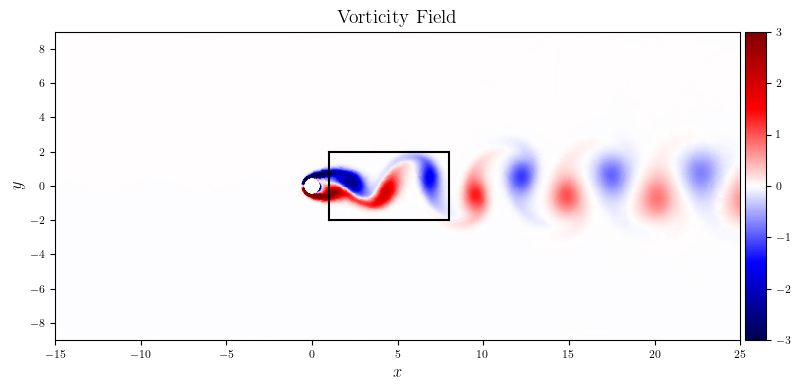

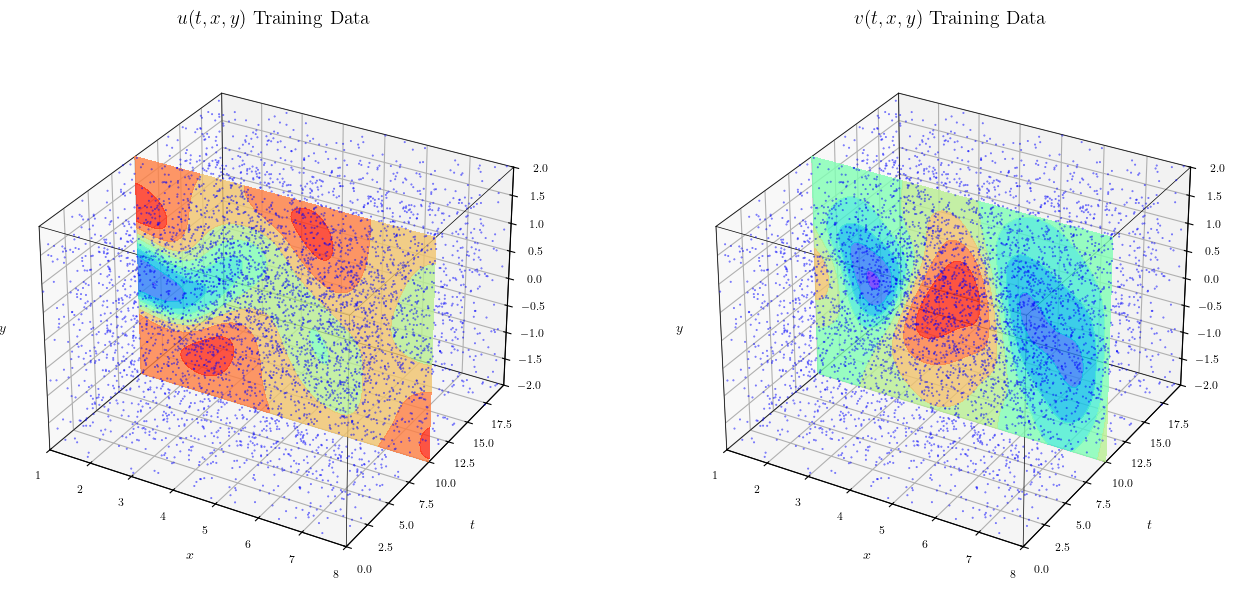

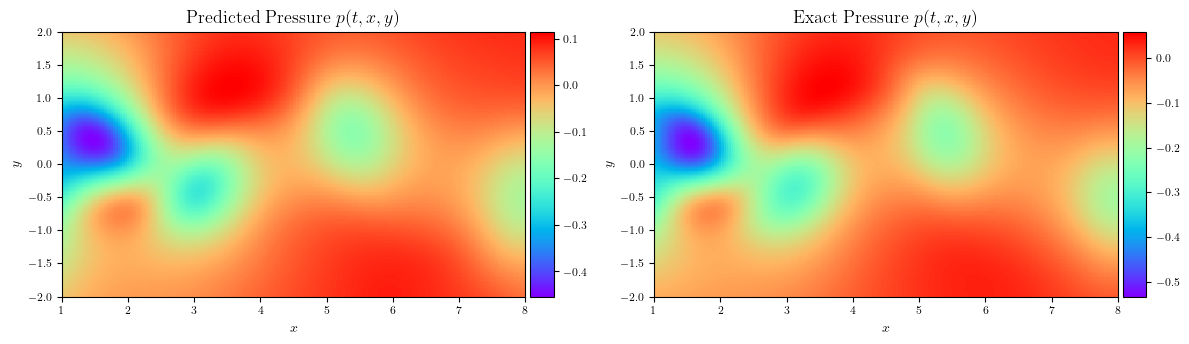

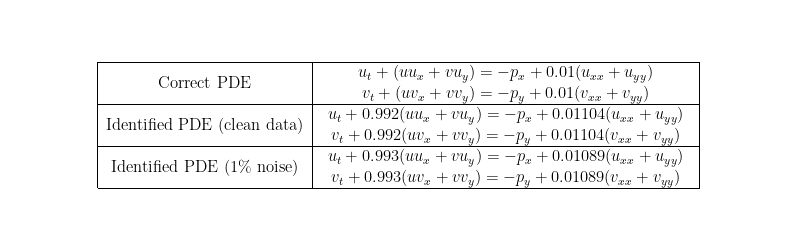

In [ ]:
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from mpl_toolkits.axes_grid1 import make_axes_locatable
from itertools import product, combinations
import scipy.io
import numpy as np

# Asegurar que las tipografías de LaTeX estén activas si se requiere
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"]
})

######################################################################
############################# Carga de Datos #########################
######################################################################
data_vort = scipy.io.loadmat('cylinder_nektar_t0_vorticity.mat')

x_vort = data_vort['x']
y_vort = data_vort['y']
w_vort = data_vort['w']
modes = data_vort['modes'].item()
nel = data_vort['nel'].item()

xx_vort = np.reshape(x_vort, (modes+1, modes+1, nel), order='F')
yy_vort = np.reshape(y_vort, (modes+1, modes+1, nel), order='F')
ww_vort = np.reshape(w_vort, (modes+1, modes+1, nel), order='F')

box_lb = np.array([1.0, -2.0])
box_ub = np.array([8.0, 2.0])


######################################################################
####################### GRÁFICA 1: Vorticity #########################
######################################################################
fig1 = plt.figure(figsize=(10, 4))
ax1 = fig1.add_subplot(111)

for i in range(0, nel):
    h1 = ax1.pcolormesh(xx_vort[:,:,i], yy_vort[:,:,i], ww_vort[:,:,i],
                        cmap='seismic', shading='gouraud', vmin=-3, vmax=3)

divider1 = make_axes_locatable(ax1)
cax1 = divider1.append_axes("right", size="3%", pad=0.05)
fig1.colorbar(h1, cax=cax1)

# Dibujar la caja delimitadora
ax1.plot([box_lb[0], box_lb[0]], [box_lb[1], box_ub[1]], 'k', linewidth=1.5)
ax1.plot([box_ub[0], box_ub[0]], [box_lb[1], box_ub[1]], 'k', linewidth=1.5)
ax1.plot([box_lb[0], box_ub[0]], [box_lb[1], box_lb[1]], 'k', linewidth=1.5)
ax1.plot([box_lb[0], box_ub[0]], [box_ub[1], box_ub[1]], 'k', linewidth=1.5)

ax1.set_aspect('equal', 'box')
ax1.set_xlabel('$x$', fontsize=12)
ax1.set_ylabel('$y$', fontsize=12)
ax1.set_title('Vorticity Field', fontsize=14)
plt.tight_layout()
plt.show()


######################################################################
##################### GRÁFICA 2: Training Data 3D ####################
######################################################################
fig2 = plt.figure(figsize=(14, 6))

r1 = [x_star.min(), x_star.max()]
r2 = [data['t'].min(), data['t'].max()]
r3 = [y_star.min(), y_star.max()]

# Combinaciones para las aristas del cubo 3D
cube_edges = []
for s, e in combinations(np.array(list(product(r1, r2, r3))), 2):
    if (np.isclose(np.sum(np.abs(s-e)), r1[1]-r1[0]) or
        np.isclose(np.sum(np.abs(s-e)), r2[1]-r2[0]) or
        np.isclose(np.sum(np.abs(s-e)), r3[1]-r3[0])):
        cube_edges.append((s, e))

######## Subplot 1: u(t,x,y) ########
ax2_1 = fig2.add_subplot(121, projection='3d')
for s, e in cube_edges:
    ax2_1.plot3D(*zip(s, e), color="k", linewidth=0.5)

ax2_1.scatter(x_train, t_train, y_train, s=0.2, alpha=0.6, color='blue')
ax2_1.contourf(X, UU_star, Y, zdir='y', offset=t_star.mean(), cmap='rainbow', alpha=0.8)

ax2_1.text(x_star.mean(), data['t'].min() - 1, y_star.min() - 1, '$x$')
ax2_1.text(x_star.max() + 1, data['t'].mean(), y_star.min() - 1, '$t$')
ax2_1.text(x_star.min() - 1, data['t'].min() - 0.5, y_star.mean(), '$y$')
ax2_1.set_title('$u(t,x,y)$ Training Data', fontsize=14, pad=20)
ax2_1.set_xlim3d(r1); ax2_1.set_ylim3d(r2); ax2_1.set_zlim3d(r3)

######## Subplot 2: v(t,x,y) ########
ax2_2 = fig2.add_subplot(122, projection='3d')
for s, e in cube_edges:
    ax2_2.plot3D(*zip(s, e), color="k", linewidth=0.5)

ax2_2.scatter(x_train, t_train, y_train, s=0.2, alpha=0.6, color='blue')
ax2_2.contourf(X, VV_star, Y, zdir='y', offset=t_star.mean(), cmap='rainbow', alpha=0.8)

ax2_2.text(x_star.mean(), data['t'].min() - 1, y_star.min() - 1, '$x$')
ax2_2.text(x_star.max() + 1, data['t'].mean(), y_star.min() - 1, '$t$')
ax2_2.text(x_star.min() - 1, data['t'].min() - 0.5, y_star.mean(), '$y$')
ax2_2.set_title('$v(t,x,y)$ Training Data', fontsize=14, pad=20)
ax2_2.set_xlim3d(r1); ax2_2.set_ylim3d(r2); ax2_2.set_zlim3d(r3)

plt.tight_layout()
plt.show()


######################################################################
####################### GRÁFICA 3: Pressure ##########################
######################################################################
fig3 = plt.figure(figsize=(12, 5))

######## Predicted pressure ########
ax3_1 = fig3.add_subplot(121)
h3_1 = ax3_1.imshow(PP_star, interpolation='nearest', cmap='rainbow',
                    extent=[x_star.min(), x_star.max(), y_star.min(), y_star.max()],
                    origin='lower', aspect='auto')
divider3_1 = make_axes_locatable(ax3_1)
cax3_1 = divider3_1.append_axes("right", size="5%", pad=0.05)
fig3.colorbar(h3_1, cax=cax3_1)
ax3_1.set_xlabel('$x$'); ax3_1.set_ylabel('$y$')
ax3_1.set_aspect('equal', 'box')
ax3_1.set_title('Predicted Pressure $p(t,x,y)$', fontsize=13)

######## Exact pressure ########
ax3_2 = fig3.add_subplot(122)
h3_2 = ax3_2.imshow(P_exact, interpolation='nearest', cmap='rainbow',
                    extent=[x_star.min(), x_star.max(), y_star.min(), y_star.max()],
                    origin='lower', aspect='auto')
divider3_2 = make_axes_locatable(ax3_2)
cax3_2 = divider3_2.append_axes("right", size="5%", pad=0.05)
fig3.colorbar(h3_2, cax=cax3_2)
ax3_2.set_xlabel('$x$'); ax3_2.set_ylabel('$y$')
ax3_2.set_aspect('equal', 'box')
ax3_2.set_title('Exact Pressure $p(t,x,y)$', fontsize=13)

plt.tight_layout()
plt.show()


######################################################################
######################## GRÁFICA 4: Tabla LaTeX ######################
######################################################################
l1_c = lambda_1_value.item() if hasattr(lambda_1_value, 'item') else lambda_1_value
l2_c = lambda_2_value.item() if hasattr(lambda_2_value, 'item') else lambda_2_value
l1_n = lambda_1_value_noisy.item() if hasattr(lambda_1_value_noisy, 'item') else lambda_1_value_noisy
l2_n = lambda_2_value_noisy.item() if hasattr(lambda_2_value_noisy, 'item') else lambda_2_value_noisy

fig4, ax4 = plt.subplots(figsize=(10, 3))
ax4.axis('off')

s = r'\begin{tabular}{|c|c|}' + \
    r' \hline' + \
    r' Correct PDE & $\begin{array}{c}' + \
    r' u_t + (u u_x + v u_y) = -p_x + 0.01 (u_{xx} + u_{yy})\\' + \
    r' v_t + (u v_x + v v_y) = -p_y + 0.01 (v_{xx} + v_{yy})' + \
    r' \end{array}$ ' + r'\\ ' + \
    r' \hline' + \
    f' Identified PDE (clean data) & $\\begin{{array}}{{c}}' + \
    f' u_t + {l1_c:.3f} (u u_x + v u_y) = -p_x + {l2_c:.5f} (u_{{xx}} + u_{{yy}})\\\\' + \
    f' v_t + {l1_c:.3f} (u v_x + v v_y) = -p_y + {l2_c:.5f} (v_{{xx}} + v_{{yy}})' + \
    f' \\end{{array}}$ ' + r'\\ ' + \
    r' \hline' + \
    f' Identified PDE (1\\% noise) & $\\begin{{array}}{{c}}' + \
    f' u_t + {l1_n:.3f} (u u_x + v u_y) = -p_x + {l2_n:.5f} (u_{{xx}} + u_{{yy}})\\\\' + \
    f' v_t + {l1_n:.3f} (u v_x + v v_y) = -p_y + {l2_n:.5f} (v_{{xx}} + v_{{yy}})' + \
    f' \\end{{array}}$ ' + r'\\ ' + \
    r' \hline' + \
    r' \end{tabular}'

ax4.text(0.5, 0.5, s, ha='center', va='center', fontsize=12)
plt.savefig('Tabla_NavierStokes.pdf', bbox_inches='tight', pad_inches=0.1)
plt.show()

# Desactivar LaTeX al terminar para no afectar otras celdas simples
plt.rcParams.update({"text.usetex": False})